<a href="https://colab.research.google.com/github/sen6eiiiii/Life-expectency-data--science-/blob/main/Coursework2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import re
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
IMDB_Data = pd.read_csv("/content/sample_data/IMDB Dataset.csv")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
list(IMDB_Data.columns.values)

['review', 'sentiment']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

In [ ]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import regularizers


# Database preprocessing

In [ ]:
IMDB_Data = IMDB_Data.sample(10000, random_state=42)
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_Text(text):
    #Convert to lowercase
    text = text.lower()
    #Remove punctuation
    text = re.sub(r'\W', ' ', text)
    #Removes HTML tags
    text = re.sub(r"<.*?>", "", text)
    #Subsititues any special character with " "
    text = re.sub(r"[^a-zA-Z]", " ", text)
    #Tokenization
    words = text.split()
    return " ".join(words)

IMDB_Data["review"]=IMDB_Data["review"].apply(preprocess_Text)
IMDB_Data["sentiment"]=IMDB_Data["sentiment"].map({"positive":1, "negative":0})

# Naive Bayes

In [ ]:
X=IMDB_Data["review"]
y=IMDB_Data["sentiment"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=125
)
model_Nb = Pipeline([
    ("vectorizer", CountVectorizer(max_features=5000)),
    ("classifier", MultinomialNB())
])
model_Nb.fit(X_train, y_train)
y_pred = model_Nb.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%\n")

Accuracy: 82.42%



## Confusion matrix

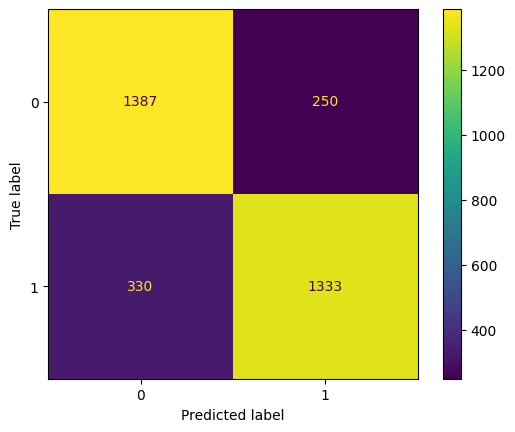

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=model_Nb.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=model_Nb.classes_)
disp.plot()
plt.show()

# Sequential and LSTM

In [ ]:
model = Sequential()
model.add(Input(shape=(200,)))
model.add(Embedding(input_dim=5000, output_dim=128, ))
model.add(LSTM(64))
model.add(Dropout(0.6))
model.add(Dense(1, activation='sigmoid', kernel_regularizer=regularizers.l2(0.001)))
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 689,473 (2.63 MB)

 Trainable params: 689,473 (2.63 MB)

 Non-trainable params: 0 (0.00 B)

## Tokenization

In [ ]:

tokenizer = Tokenizer(num_words=2000, filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n')
tokenizer.fit_on_texts(IMDB_Data["review"])
sequences = tokenizer.texts_to_sequences(IMDB_Data["review"])
X = pad_sequences(sequences, maxlen=200)
y = IMDB_Data["sentiment"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Early Stopping

In [ ]:

early_stop = EarlyStopping(monitor='val_loss', patience=2)
history = model.fit(
    X_train, y_train,
    epochs=32,
    batch_size=512,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
)


Epoch 1/32
16/16 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.5788 - loss: 0.6894 - val_accuracy: 0.6365 - val_loss: 0.6726
Epoch 2/32
16/16 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.7241 - loss: 0.5885 - val_accuracy: 0.7410 - val_loss: 0.5292
Epoch 3/32
16/16 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.8086 - loss: 0.4364 - val_accuracy: 0.8205 - val_loss: 0.4145
Epoch 4/32
16/16 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.8618 - loss: 0.3509 - val_accuracy: 0.8290 - val_loss: 0.4250
Epoch 5/32
16/16 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.8836 - loss: 0.3061 - val_accuracy: 0.8475 - val_loss: 0.3472
Epoch 6/32
16/16 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.9056 - loss: 0.2591 - val_accuracy: 0.8580 - val_loss: 0.3384
Epoch 7/32
16/16 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.9196 - loss: 0.2285 - val_accuracy: 0.8555 - val_loss: 0.3508
Epoch 8/32
16/16 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.9227 - loss: 0.2195 - val_accuracy: 0.8550 - val_loss:

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Accuracy: {accuracy * 100:.2f}%\n")

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.8550 - loss: 0.3506
Accuracy: 85.50%



In [ ]:
y_pred = (model.predict(X_test) > 0.5).astype("int32") # Binary classification label is determined using the threshold 0.5.
print("\nClassification Report:\n", classification_report(y_test, y_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.87      0.86       999
           1       0.86      0.84      0.85      1001

    accuracy                           0.85      2000
   macro avg       0.86      0.86      0.85      2000
weighted avg       0.86      0.85      0.85      2000



## Confusion matrix

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step


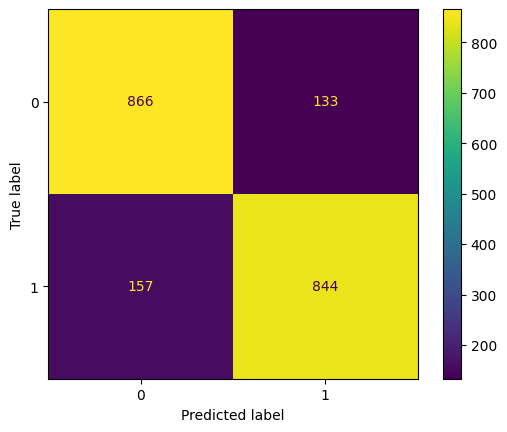

In [ ]:
y_pred = (model.predict(X_test) > 0.5).astype("int32")

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


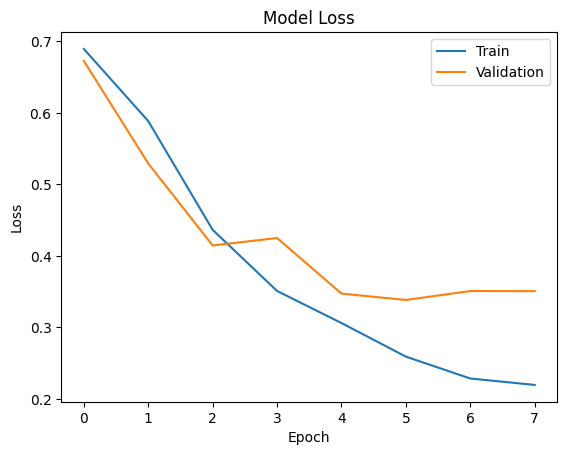

In [ ]:
print(history.history.keys())
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])
plt.show()

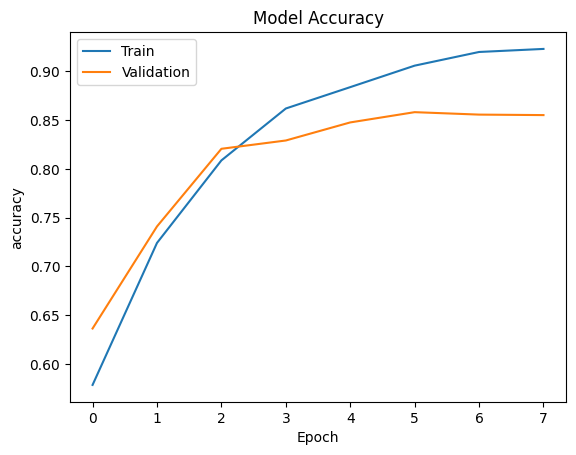

In [ ]:
plt.title('Model Accuracy')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.show()


# Hyperparameter Tuning



In [ ]:

!pip install keras-tuner --upgrade
import keras
import keras_tuner
def build_model(hp):
    model = keras.Sequential()
    model.add(keras.layers.Embedding(input_dim=5000, output_dim=128, ))
    model.add(keras.layers.LSTM(64))
    model.add(Dropout(0.6))
    model.add(keras.layers.Dense(
        units=hp.Int('units', min_value=8, max_value=128, step=8),
        activation='sigmoid', kernel_regularizer=regularizers.l2(0.001)))
    model.compile(
        optimizer=keras.optimizers.Adam(
            hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')),
        loss='mse',
        metrics=['accuracy'])
    return model
tuner = keras_tuner.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=10,
    executions_per_trial=1,
    directory='my_dir',
    project_name='keras_tuner_demo')
tuner.search(X_train, y_train, epochs=8, validation_data=(X_test, y_test), validation_split=0.2)
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best units: {best_hp.get('units')}")
print(f"Best learning rate: {best_hp.get('learning_rate')}")

Trial 10 Complete [00h 05m 05s]
val_loss: 0.14049406349658966

Best val_loss So Far: 0.11565549671649933
Total elapsed time: 00h 55m 20s
Best units: 16
Best learning rate: 0.0002253374765329313


In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=2)
model = tuner.hypermodel.build(best_hp)
history=model.fit(
    X_train, y_train,
    epochs=32,
    batch_size=512,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
    )
#test 512 batch size 1

Epoch 1/32
16/16 ━━━━━━━━━━━━━━━━━━━━ 48s 3s/step - accuracy: 0.0654 - loss: 0.2760 - val_accuracy: 0.0615 - val_loss: 0.2753
Epoch 2/32
16/16 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.0749 - loss: 0.2747 - val_accuracy: 0.0630 - val_loss: 0.2740
Epoch 3/32
16/16 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.0579 - loss: 0.2732 - val_accuracy: 0.0495 - val_loss: 0.2723
Epoch 4/32
16/16 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.0481 - loss: 0.2695 - val_accuracy: 0.0120 - val_loss: 0.2638
Epoch 5/32
16/16 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.0884 - loss: 0.2572 - val_accuracy: 0.1850 - val_loss: 0.2484
Epoch 6/32
16/16 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.1175 - loss: 0.2441 - val_accuracy: 0.1625 - val_loss: 0.2342
Epoch 7/32
16/16 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.1100 - loss: 0.2281 - val_accuracy: 0.1030 - val_loss: 0.2171
Epoch 8/32
16/16 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.1095 - loss: 0.2118 - val_accuracy: 0.1285 - val_loss:

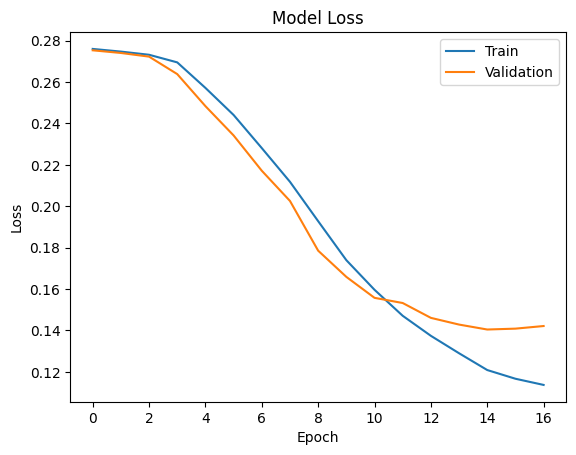

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])
plt.show()

## Model accuracy

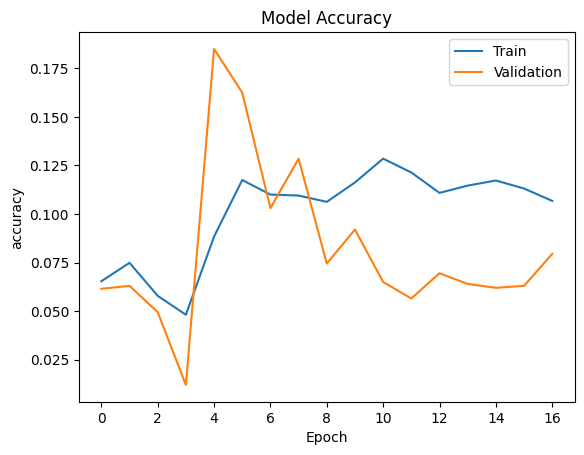

In [ ]:
plt.title('Model Accuracy')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.show()


In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=2)
model = tuner.hypermodel.build(best_hp)
history=model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=512,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
    )


Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step - accuracy: 0.1004 - loss: 0.2741 - val_accuracy: 0.1135 - val_loss: 0.2735
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.0938 - loss: 0.2729 - val_accuracy: 0.1005 - val_loss: 0.2723
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.0860 - loss: 0.2715 - val_accuracy: 0.0800 - val_loss: 0.2709
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.0838 - loss: 0.2694 - val_accuracy: 0.1055 - val_loss: 0.2671
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.1129 - loss: 0.2581 - val_accuracy: 0.3215 - val_loss: 0.2447
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.1270 - loss: 0.2438 - val_accuracy: 0.4205 - val_loss: 0.2342
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.1555 - loss: 0.2287 - val_accuracy: 0.4205 - val_loss: 0.2215
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.1539 - loss: 0.2130 - val_accuracy: 0.2905 - val_loss:

In [ ]:
y_pred = (model.predict(X_test) > 0.5).astype("int32")

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()
#test 512 batch size 2

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step


ValueError: Classification metrics can't handle a mix of binary and multilabel-indicator targets